# Visualize Fused Features

Use this notebook to inspect the fused feature `.pt` files saved during local evaluation.

Set `FEATURES_DIR` to a route feature folder, for example:

```python
FEATURES_DIR = Path("/path/to/features/route_name_05_06_15_20_00")
```

If the run used an ensemble, point `FEATURES_DIR` at one model folder such as `model_00`, or leave it at the route folder and set `MODEL_SUBDIR` below.

In [19]:
from pathlib import Path

import matplotlib

# Compatibility for newer IPython/matplotlib-inline with older matplotlib.
if not hasattr(matplotlib.rcParams, "_get"):
    matplotlib.rcParams._get = matplotlib.rcParams.get

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

plt.rcParams["figure.dpi"] = 130

# Edit these paths.
DEBUG_ROOT = Path("/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug")
VIS_ROOT = Path("/media/hcis-s20/SRL/osu_fail2drive/fail2drive/viz_vehicle")

VEHICLE_ROUTE_NAME = "Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45"
NO_VEHICLE_ROUTE_NAME = "Generalization_NoVehicleOnRoad_1085_route0_05_06_18_22_39"

VEHICLE_FEATURES_DIR = DEBUG_ROOT / VEHICLE_ROUTE_NAME
NO_VEHICLE_FEATURES_DIR = DEBUG_ROOT / NO_VEHICLE_ROUTE_NAME

# Main features to visualize. For activation steering this is usually the vehicle-on-road run.
FEATURES_DIR = VEHICLE_FEATURES_DIR

# Optional: folder containing visualize_model outputs. Leave None if unavailable.
VIS_DIR = VIS_ROOT / VEHICLE_ROUTE_NAME

APPLY_STEERING = True
STEERING_ALPHA = 1.0
STEERING_MIN_FRAMES = 200  # None means use all common frames.
STEERING_MAX_FRAMES = 239  # None means use all common frames.

print("FEATURES_DIR:", FEATURES_DIR.resolve())
print("VEHICLE_FEATURES_DIR:", VEHICLE_FEATURES_DIR.resolve())
print("NO_VEHICLE_FEATURES_DIR:", NO_VEHICLE_FEATURES_DIR.resolve())
print("APPLY_STEERING:", APPLY_STEERING, "alpha:", STEERING_ALPHA)
print("VIS_DIR:", None if VIS_DIR is None else Path(VIS_DIR).resolve())

FEATURES_DIR: /media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45
VEHICLE_FEATURES_DIR: /media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45
NO_VEHICLE_FEATURES_DIR: /media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_NoVehicleOnRoad_1085_route0_05_06_18_22_39
APPLY_STEERING: True alpha: 1.0
VIS_DIR: /media/hcis-s20/SRL/osu_fail2drive/fail2drive/viz_vehicle/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45


In [2]:
def list_feature_files(features_dir):
    features_dir = Path(features_dir)
    files = sorted(features_dir.glob("*.pt"))
    if not files:
        files = sorted(features_dir.rglob("*.pt"))
    return files


feature_files = list_feature_files(FEATURES_DIR)
feature_files = feature_files[200:231]
print(f"Found {len(feature_files)} feature files")
for path in feature_files[:5]:
    print(path)

if not feature_files:
    raise FileNotFoundError(f"No .pt files found under {FEATURES_DIR}")

Found 31 feature files
/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45/000205.pt
/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45/000206.pt
/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45/000207.pt
/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45/000208.pt
/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45/000209.pt


In [3]:
def load_feature(path):
    feat = torch.load(path, map_location="cpu")
    if isinstance(feat, dict):
        for key in ("fused_features", "features", "feat"):
            if key in feat:
                feat = feat[key]
                break
    if not torch.is_tensor(feat):
        feat = torch.as_tensor(feat)
    return feat.float()


def feature_to_tokens(feat):
    """Return tokens as [num_tokens, channels]. Handles common saved shapes."""
    feat = feat.detach().cpu().float()
    if feat.ndim >= 1 and feat.shape[0] == 1:
        feat = feat.squeeze(0)

    if feat.ndim == 1:
        return feat[None, :]
    if feat.ndim == 2:
        return feat
    if feat.ndim == 3:
        # [C, H, W] -> [H*W, C]
        if feat.shape[0] <= feat.shape[-1] and feat.shape[1] == feat.shape[2]:
            return feat.permute(1, 2, 0).reshape(-1, feat.shape[0])
        return feat.reshape(-1, feat.shape[-1])
    if feat.ndim == 4:
        # [B, C, H, W] after optional batch squeeze fallback.
        feat = feat.reshape(-1, *feat.shape[-3:])
        feat = feat[0]
        return feat.permute(1, 2, 0).reshape(-1, feat.shape[0])
    raise ValueError(f"Unsupported feature shape: {tuple(feat.shape)}")


def infer_spatial_token_count(num_tokens):
    root = int(np.sqrt(num_tokens))
    if root * root == num_tokens:
        return num_tokens, root, root

    root = int(np.sqrt(num_tokens - 1))
    if root * root == num_tokens - 1:
        return num_tokens - 1, root, root

    root = int(np.sqrt(num_tokens))
    return root * root, root, root


def normalize01(x, eps=1e-8):
    x = np.asarray(x, dtype=np.float32)
    return (x - x.min()) / (x.max() - x.min() + eps)


def pca_rgb(tokens):
    x = tokens.detach().cpu().numpy().astype(np.float32)
    x = x - x.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(x, full_matrices=False)
    rgb = x @ vh[:3].T
    return normalize01(rgb)


def frame_idx_from_path(path):
    try:
        return int(Path(path).stem)
    except ValueError:
        return None


def find_visualization(vis_dir, frame_idx):
    if vis_dir is None or frame_idx is None:
        return None
    vis_dir = Path(vis_dir)
    candidates = []
    for stem in (f"{frame_idx:04d}", f"{frame_idx:06d}", str(frame_idx)):
        for suffix in (".png", ".jpg", ".jpeg"):
            candidates.append(vis_dir / f"{stem}{suffix}")
    return next((path for path in candidates if path.exists()), None)

In [4]:
# Activation steering: vehicle-on-road mean minus no-vehicle-on-road mean.
# The steering direction is a [num_tokens, channels] tensor and is added before visualization.
def files_by_frame(files):
    out = {}
    for path in files:
        frame_idx = frame_idx_from_path(path)
        if frame_idx is not None:
            out[frame_idx] = path
    return out


def common_frame_files(vehicle_dir, no_vehicle_dir, max_frames=None, min_frames=None):
    vehicle_by_frame = files_by_frame(list_feature_files(vehicle_dir))
    no_vehicle_by_frame = files_by_frame(list_feature_files(no_vehicle_dir))
    common_frames = sorted(set(vehicle_by_frame) & set(no_vehicle_by_frame))
    if max_frames is not None:
        common_frames = common_frames[:max_frames]
    if min_frames is not None:
        common_frames = common_frames[min_frames:]
    vehicle_files = [vehicle_by_frame[idx] for idx in common_frames]
    no_vehicle_files = [no_vehicle_by_frame[idx] for idx in common_frames]
    return common_frames, vehicle_files, no_vehicle_files


def mean_tokens(files):
    total = None
    count = 0
    expected_shape = None
    for path in files:
        tokens_i = feature_to_tokens(load_feature(path).flip(2))
        if expected_shape is None:
            expected_shape = tokens_i.shape
            total = torch.zeros_like(tokens_i)
        if tokens_i.shape != expected_shape:
            print(f"skip shape mismatch: {path.name} {tuple(tokens_i.shape)} != {tuple(expected_shape)}")
            continue
        total += tokens_i
        count += 1
    if count == 0:
        raise ValueError("No compatible feature tensors were found")
    return total / count


def compute_steering_direction(vehicle_dir, no_vehicle_dir, min_frames=None, max_frames=None):
    common_frames, vehicle_files, no_vehicle_files = common_frame_files(vehicle_dir, no_vehicle_dir, max_frames, min_frames)
    if not common_frames:
        raise ValueError("No common frame ids between vehicle and no-vehicle feature folders")
    vehicle_mean = mean_tokens(vehicle_files)
    no_vehicle_mean = mean_tokens(no_vehicle_files)
    direction = vehicle_mean - no_vehicle_mean
    return direction, vehicle_mean, no_vehicle_mean, common_frames, vehicle_files, no_vehicle_files


def apply_activation_steering(tokens):
    if not APPLY_STEERING or STEERING_DIRECTION is None:
        return tokens
    if tokens.shape != STEERING_DIRECTION.shape:
        raise ValueError(f"Steering shape {tuple(STEERING_DIRECTION.shape)} does not match tokens {tuple(tokens.shape)}")
    return tokens + STEERING_ALPHA * STEERING_DIRECTION


STEERING_DIRECTION = None
VEHICLE_MEAN_TOKENS = None
NO_VEHICLE_MEAN_TOKENS = None
STEERING_COMMON_FRAMES = []

if APPLY_STEERING:
    STEERING_DIRECTION, VEHICLE_MEAN_TOKENS, NO_VEHICLE_MEAN_TOKENS, STEERING_COMMON_FRAMES, vehicle_files, no_vehicle_files = compute_steering_direction(
        VEHICLE_FEATURES_DIR,
        NO_VEHICLE_FEATURES_DIR,
        min_frames=STEERING_MIN_FRAMES,
        max_frames=STEERING_MAX_FRAMES,
    )
    print("steering common frames:", len(STEERING_COMMON_FRAMES), STEERING_COMMON_FRAMES[:5], "...")
    print("steering direction shape:", tuple(STEERING_DIRECTION.shape))
    print("steering direction rms:", float(torch.sqrt(torch.mean(STEERING_DIRECTION ** 2))))
else:
    print("activation steering disabled")

/tmp/ipykernel_369823/4049843939.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feat = torch.load(path, map_location="cpu")


RuntimeError: The size of tensor a (8) must match the size of tensor b (64) at non-singleton dimension 1

In [5]:
# Visualize the steering direction itself.
if APPLY_STEERING and STEERING_DIRECTION is not None:
    spatial_s, steer_h, steer_w = infer_spatial_token_count(STEERING_DIRECTION.shape[0])
    vehicle_mean_norm = torch.linalg.norm(VEHICLE_MEAN_TOKENS[:spatial_s], dim=1).numpy().reshape(steer_h, steer_w)
    no_vehicle_mean_norm = torch.linalg.norm(NO_VEHICLE_MEAN_TOKENS[:spatial_s], dim=1).numpy().reshape(steer_h, steer_w)
    direction_norm = torch.linalg.norm(STEERING_DIRECTION[:spatial_s], dim=1).numpy().reshape(steer_h, steer_w)
    direction_mean = STEERING_DIRECTION[:spatial_s].mean(dim=1).numpy().reshape(steer_h, steer_w)

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
    axes[0].imshow(vehicle_mean_norm, cmap="magma")
    axes[0].set_title("vehicle mean norm")
    axes[1].imshow(no_vehicle_mean_norm, cmap="magma")
    axes[1].set_title("no vehicle mean norm")
    axes[2].imshow(direction_norm, cmap="magma")
    axes[2].set_title("direction norm")
    axes[3].imshow(direction_mean, cmap="coolwarm")
    axes[3].set_title("direction mean")
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(f"mean(vehicle) - mean(no vehicle), {len(STEERING_COMMON_FRAMES)} common frames", y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("No steering direction to visualize")

No steering direction to visualize


[PosixPath('/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45/000205.pt'), PosixPath('/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45/000206.pt'), PosixPath('/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45/000207.pt'), PosixPath('/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45/000208.pt'), PosixPath('/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45/000209.pt'), PosixPath('/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45/000210.pt'), PosixPath('/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_13_15_53_45/000211.pt'), PosixPath('/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalizati

/tmp/ipykernel_369823/4049843939.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feat = torch.load(path, map_location="cpu")


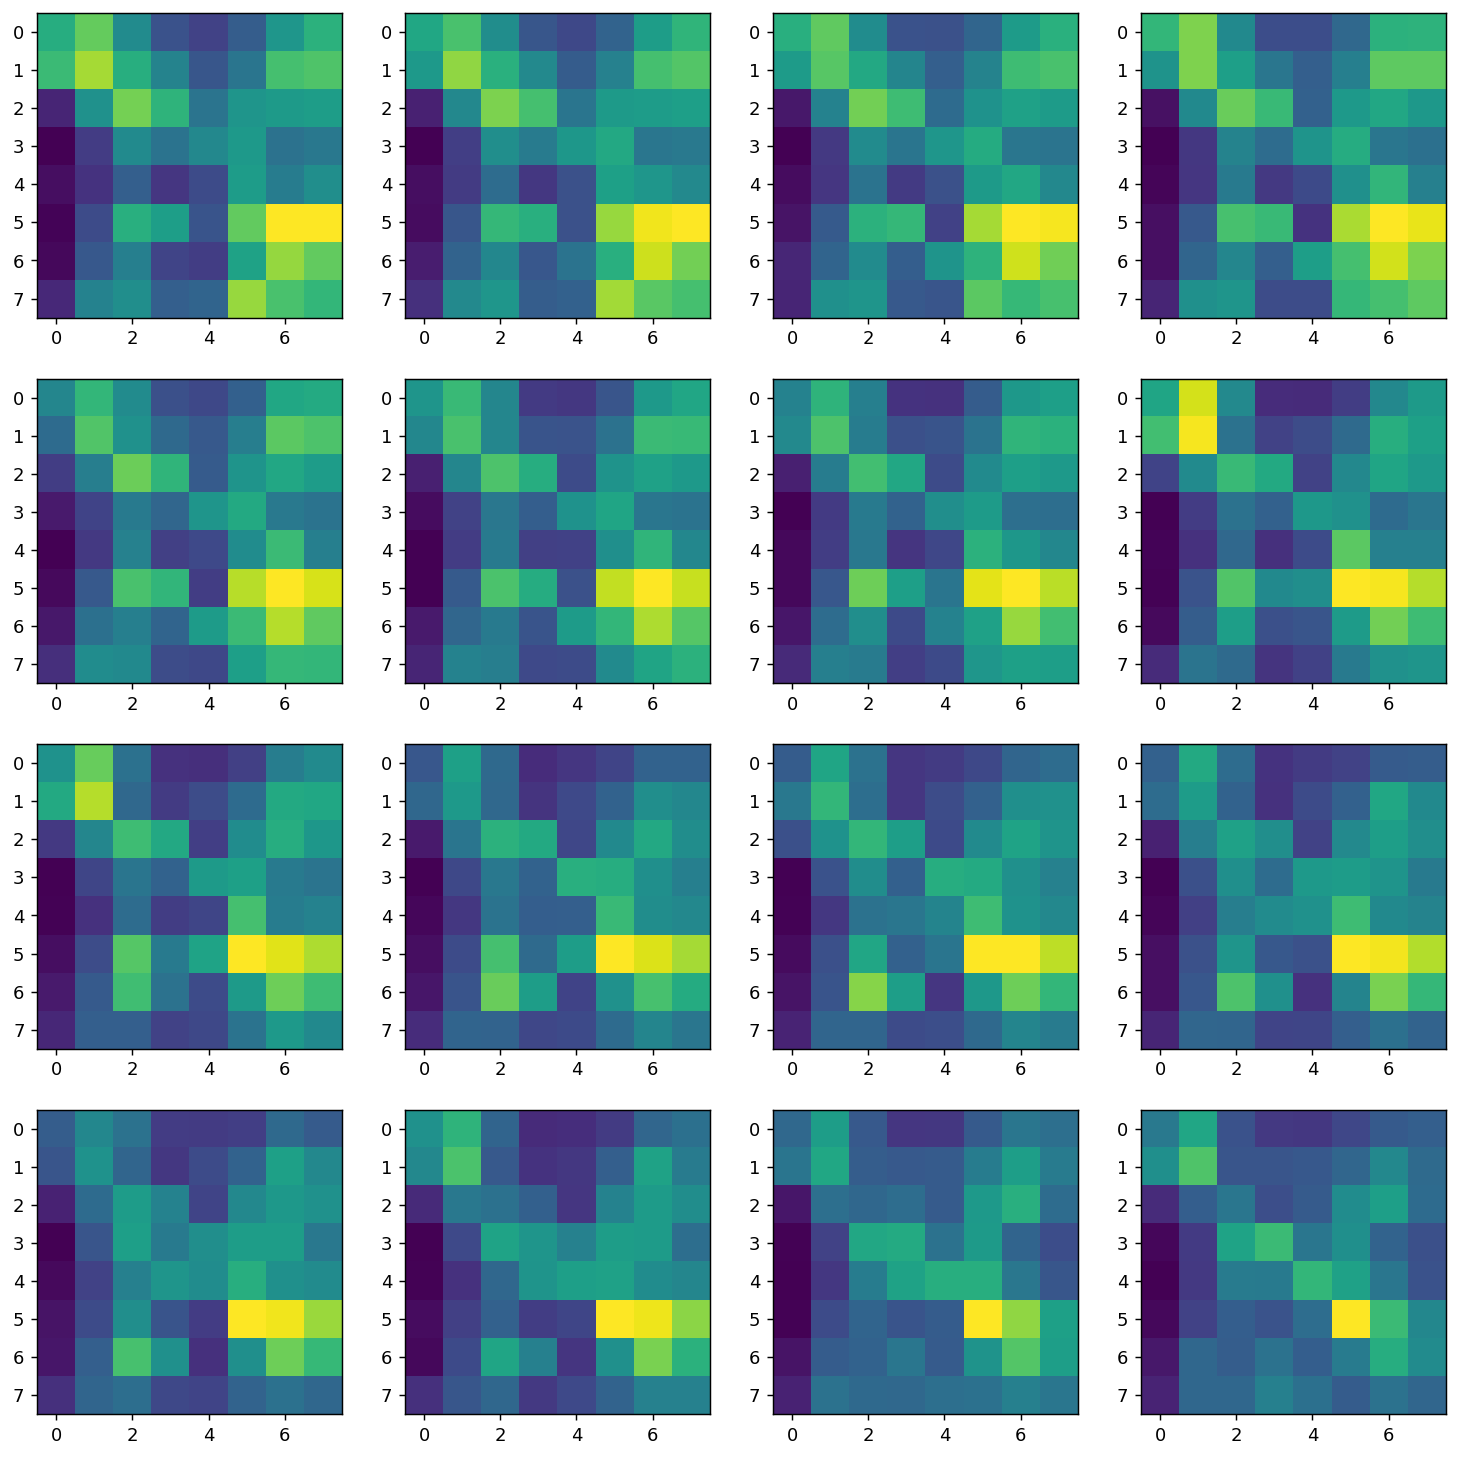

In [8]:
from sklearn.decomposition import PCA
def pca_2d(feats):
    C, H, W = feats.shape
    features_flat = feats.view(C, -1).permute(1, 0)

    # 將 tensor 轉為 numpy array 以供 sklearn 使用
    features_np = features_flat.cpu().numpy()

    # 2 & 3. 建立並擬合 PCA，將維度從 C 降到 3 (用於 RGB 視覺化)
    pca = PCA(n_components=3)
    pca_features = pca.fit_transform(features_np) # 輸出 shape: (H*W, 3)

    # 4. 還原成 2D 空間結構：(H*W, 3) -> (H, W, 3)
    pca_feature_map = pca_features.reshape(H, W, 3)

    # 5. 正規化 (Min-Max Scaling) 到 [0, 1] 區間
    min_val = pca_feature_map.min(axis=(0, 1), keepdims=True)
    max_val = pca_feature_map.max(axis=(0, 1), keepdims=True)
    pca_normalized = (pca_feature_map - min_val) / (max_val - min_val)
    return pca_normalized

vehicle_by_frame = files_by_frame(list_feature_files(VEHICLE_FEATURES_DIR))
vehicle_files = [vehicle_by_frame[idx] for idx in vehicle_by_frame]
vehicle_files = vehicle_files[STEERING_MIN_FRAMES:STEERING_MIN_FRAMES+32]
print(vehicle_files)
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for i in range(16):
    j = i * 2
    with_vehicle_index = load_feature(vehicle_files[j])
    # no_vehicle_index = load_feature(no_vehicle_files[j]).flip(2)
    # delta_F = with_vehicle_index[0] - no_vehicle_index[0]
    # plt.imsave(f"./viz_vehicle/test/frame_{i:04d}.png", torch.mean(torch.abs(with_vehicle_index[0].permute(1,2,0)), dim=2).numpy(), cmap="magma")
    # plt.imshow(pca_2d(with_vehicle_index[0] - no_vehicle_index[0]))
    # axes[i//4, i%4].imshow(torch.mean(torch.abs(delta_F.permute(1,2,0)), dim=2))
    axes[i//4, i%4].imshow(torch.mean(torch.abs(with_vehicle_index[0].permute(1,2,0)), dim=2))

torch.Size([1512, 8, 8])


/tmp/ipykernel_369823/4049843939.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feat = torch.load(path, map_location="cpu")


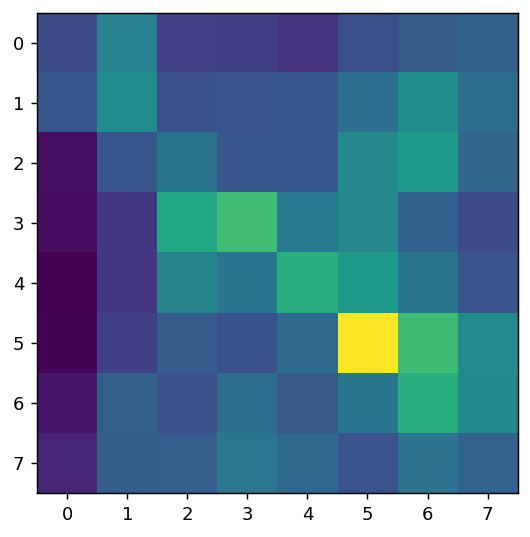

In [19]:
alpha_f = load_feature(vehicle_files[31])[0]
print(alpha_f.shape)
plt.imshow(torch.mean(torch.abs(alpha_f.permute(1,2,0)), dim=2))
torch.save(alpha_f[:, 5, 5], "./steering/steering_region_last_layer.pt")

In [5]:
with_vehicle_index.shape

NameError: name 'with_vehicle_index' is not defined

/tmp/ipykernel_319512/4049843939.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feat = torch.load(path, map_location="cpu")


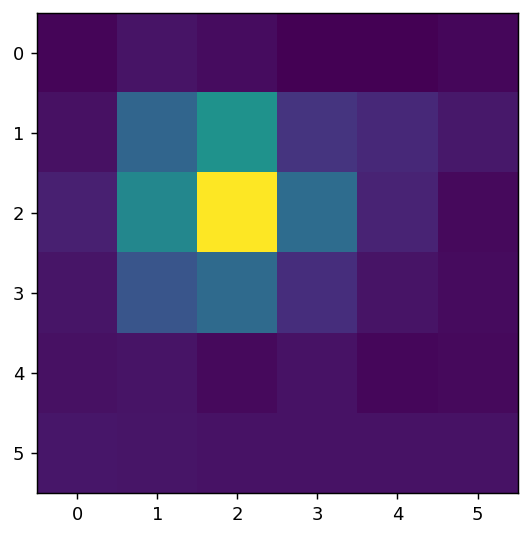

In [11]:
with_vehicle_index = load_feature(vehicle_files[11])
norm_feats = torch.mean(torch.abs(with_vehicle_index[0].permute(1,2,0)), dim=2)
x1, x2 = 30, 36
y1, y2 = 36, 42
plt.imshow(norm_feats[x1:x2, y1:y2])
# plt.imshow(norm_feats)
torch.save(with_vehicle_index[0, :, x1:x2, y1:y2], "./steering/steering_region.pt")

/tmp/ipykernel_319512/4049843939.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feat = torch.load(path, map_location="cpu")


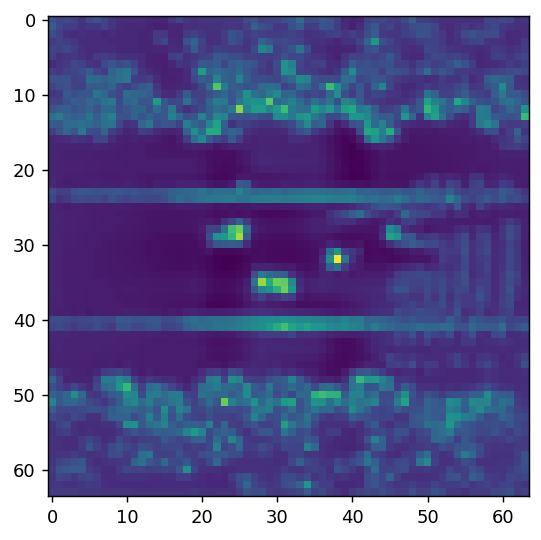

In [8]:
with_vehicle_index = load_feature(vehicle_files[11])
norm_feats = torch.mean(torch.abs(with_vehicle_index[0].permute(1,2,0)), dim=2)
plt.imshow(norm_feats)

tensor([[[ 3.7622e-01,  9.8975e-01,  5.0878e-01,  2.6681e-01,  6.3139e-01,
           4.8059e-01],
         [ 4.0244e-01,  3.6942e-01,  3.3641e-01,  3.0339e-01,  8.8301e-01,
           9.3581e-01],
         [ 1.0865e+00,  1.4615e+00,  3.6954e-01,  8.9153e-01,  3.9449e-01,
           1.0117e+00],
         [ 1.2210e+00,  9.8401e-01,  4.0266e-01,  3.7656e-01,  7.3579e-01,
           7.8405e-01],
         [ 4.8109e-01,  1.0198e+00,  4.3579e-01,  4.1314e-01,  3.9049e-01,
           4.7988e-01],
         [ 5.0731e-01,  4.8812e-01,  4.6892e-01,  4.4972e-01,  4.3053e-01,
           4.1133e-01]],

        [[-4.5708e-01, -4.5440e-01,  2.4103e-01, -1.0317e-01, -2.1845e-01,
          -4.4369e-01],
         [-4.0482e-01,  5.3553e-01,  3.5597e+00,  1.0568e+00,  7.4724e-01,
           6.3745e-01],
         [-3.5257e-01,  6.5640e-01,  2.7178e+00,  9.8302e-01, -3.1315e-01,
          -3.0355e-01],
         [-3.0031e-01, -2.8694e-01, -2.7095e-01, -2.6021e-01, -2.1808e-01,
          -5.4107e-02],
        

/tmp/ipykernel_319512/3702729919.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load("./steering/steering_region.pt")


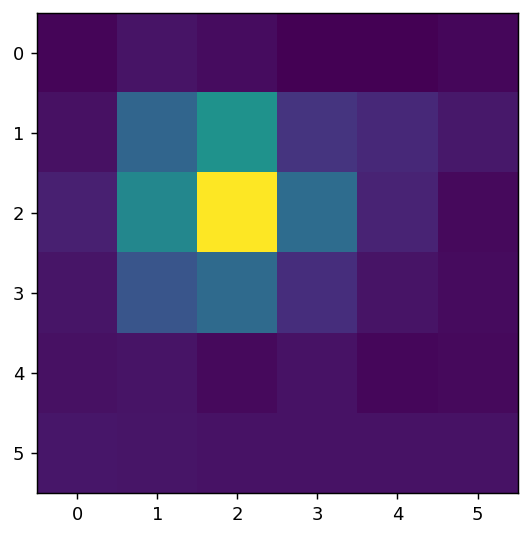

In [19]:
x = torch.load("./steering/steering_region.pt")
print(x)
plt.imshow(torch.mean(torch.abs(x.permute(1,2,0)), dim=2))

In [10]:
with_vehicle_index[0, :, x1:x2, y1:y2].shape

torch.Size([32, 8, 10])

In [ ]:
# Pick a frame by index in the sorted file list.
FILE_INDEX = 0

feature_path = feature_files[FILE_INDEX]
feat = load_feature(feature_path)
raw_tokens = feature_to_tokens(feat)
tokens = apply_activation_steering(raw_tokens)
spatial_tokens, grid_h, grid_w = infer_spatial_token_count(tokens.shape[0])
frame_idx = frame_idx_from_path(feature_path)

print("feature_path:", feature_path)
print("frame_idx:", frame_idx)
print("raw shape:", tuple(feat.shape))
print("raw tokens shape:", tuple(raw_tokens.shape))
print("tokens shape:", tuple(tokens.shape), "steered" if APPLY_STEERING else "raw")
print("spatial tokens:", spatial_tokens, "grid:", (grid_h, grid_w))
if spatial_tokens != tokens.shape[0]:
    print("non-spatial tokens:", tokens.shape[0] - spatial_tokens)

feature_path: /media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_06_18_26_03/000205.pt
frame_idx: 205
raw shape: (1, 64, 64, 64)
raw tokens shape: (4096, 64)
tokens shape: (4096, 64) steered
spatial tokens: 4096 grid: (64, 64)


/tmp/ipykernel_308079/4049843939.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feat = torch.load(path, map_location="cpu")


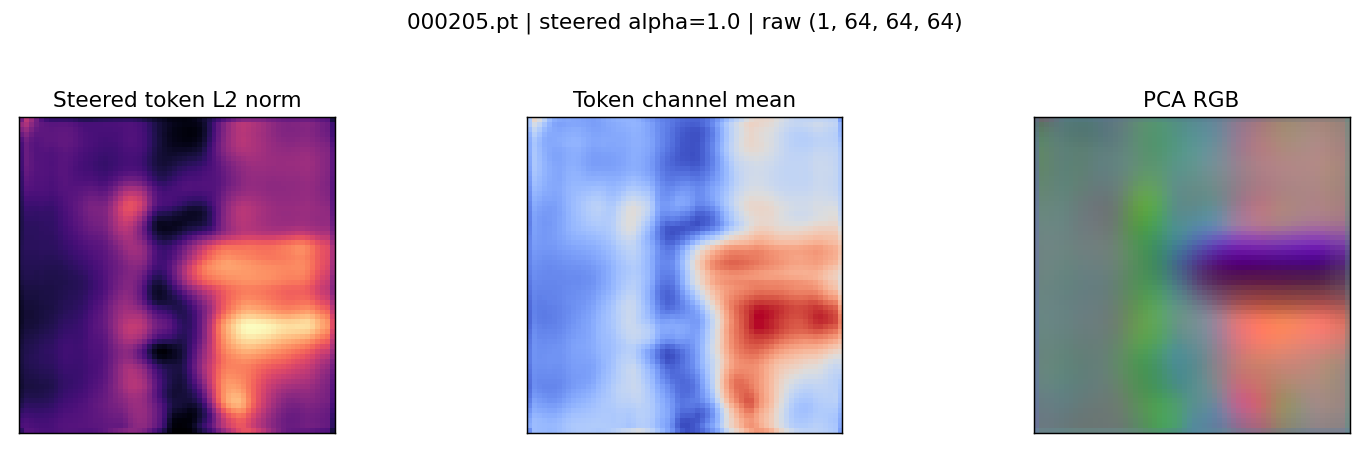

In [ ]:
spatial = tokens[:spatial_tokens]
norm_map = torch.linalg.norm(spatial, dim=1).numpy().reshape(grid_h, grid_w)
mean_map = spatial.mean(dim=1).numpy().reshape(grid_h, grid_w)
pca_map = pca_rgb(spatial).reshape(grid_h, grid_w, 3)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
axes[0].imshow(norm_map, cmap="magma")
axes[0].set_title("Steered token L2 norm" if APPLY_STEERING else "Token L2 norm")
axes[1].imshow(mean_map, cmap="coolwarm")
axes[1].set_title("Token channel mean")
axes[2].imshow(pca_map)
axes[2].set_title("PCA RGB")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

mode = f"steered alpha={STEERING_ALPHA}" if APPLY_STEERING else "raw"
fig.suptitle(f"{feature_path.name} | {mode} | raw {tuple(feat.shape)}", y=1.04)
plt.tight_layout()
plt.show()

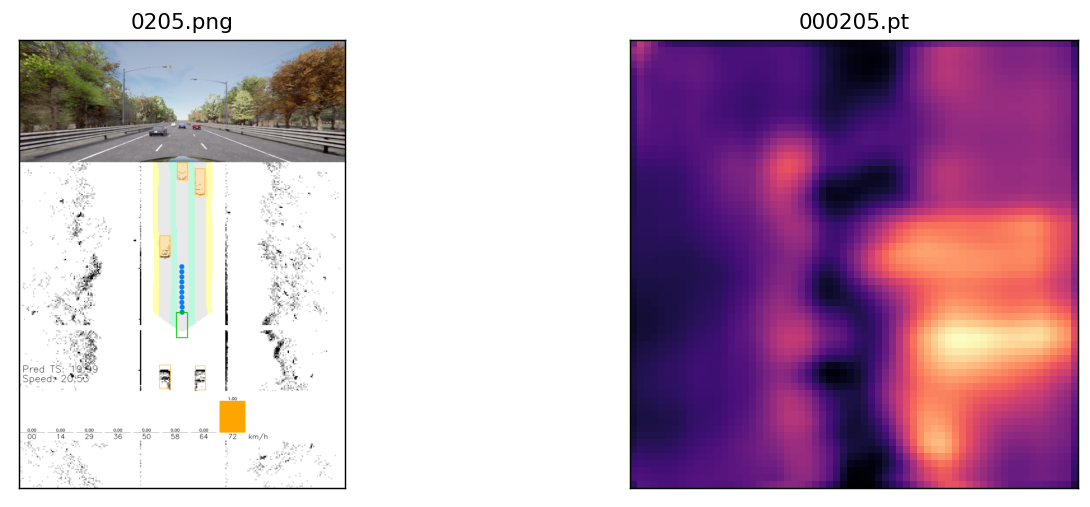

In [ ]:
# Optional: show the matching visualize_model frame next to the feature heatmap.
vis_path = find_visualization(VIS_DIR, frame_idx)

if vis_path is None:
    print("No matching visualization found. Set VIS_DIR if you want side-by-side comparison.")
else:
    image = Image.open(vis_path).convert("RGB")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(image)
    axes[0].set_title(vis_path.name)
    axes[1].imshow(norm_map, cmap="magma")
    axes[1].set_title(feature_path.name)
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()
    plt.show()

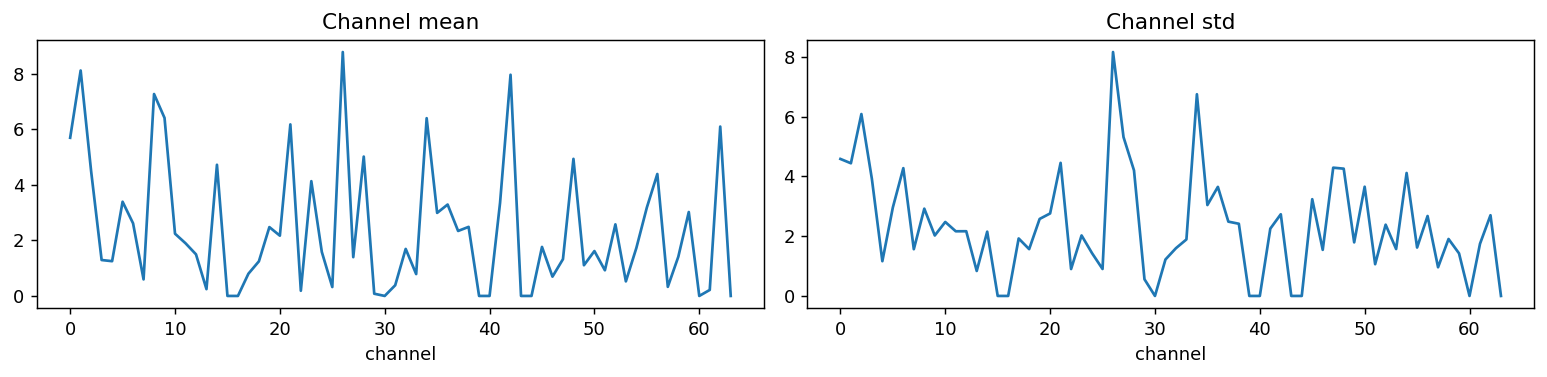

In [ ]:
# Inspect channel statistics for the selected frame.
channel_mean = tokens.mean(dim=0).numpy()
channel_std = tokens.std(dim=0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(channel_mean)
axes[0].set_title("Channel mean")
axes[0].set_xlabel("channel")
axes[1].plot(channel_std)
axes[1].set_title("Channel std")
axes[1].set_xlabel("channel")
plt.tight_layout()
plt.show()

/tmp/ipykernel_308079/4049843939.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feat = torch.load(path, map_location="cpu")


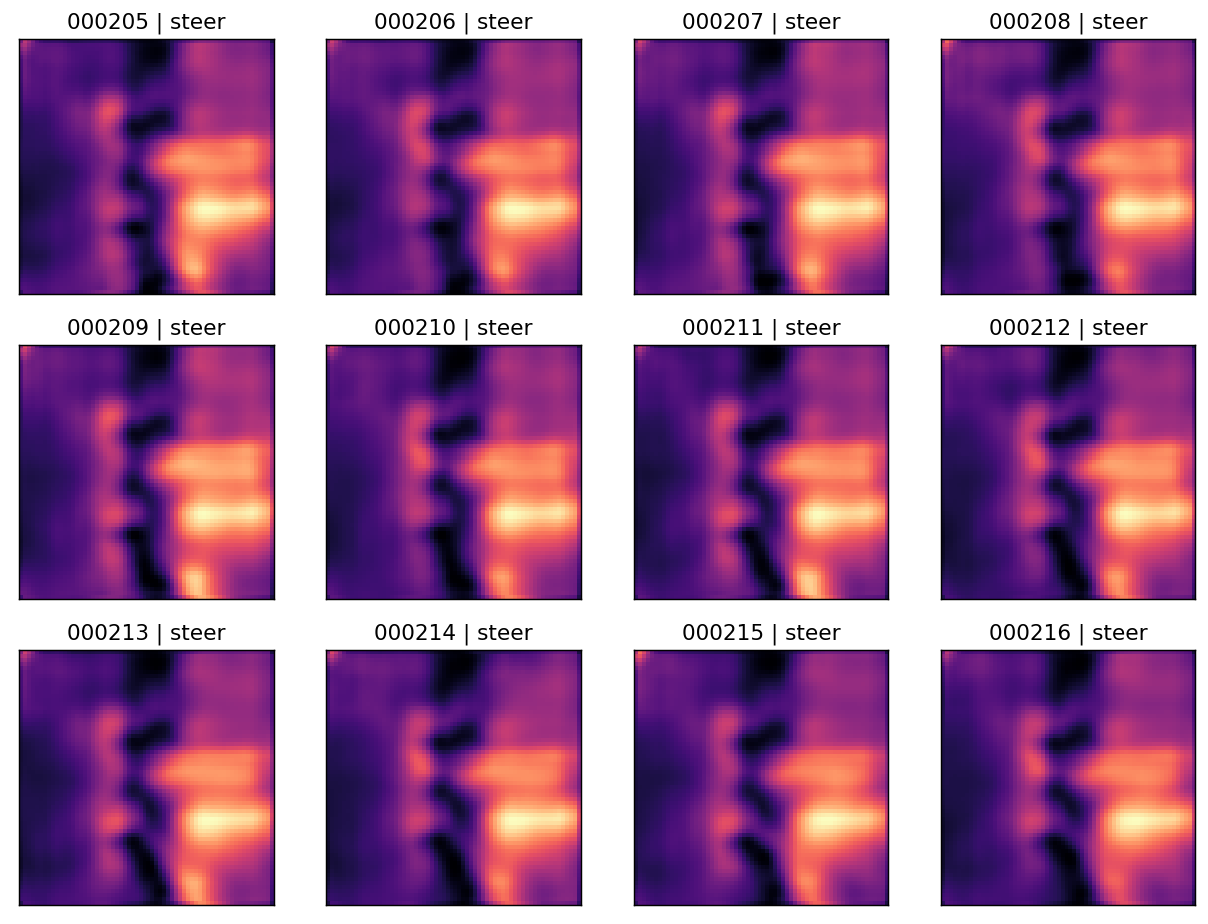

In [ ]:
# Montage across frames using token norm heatmaps.
START = 0
COUNT = 12
COLS = 4

selected_files = feature_files[START:START + COUNT]
rows = int(np.ceil(len(selected_files) / COLS))
fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 2.4, rows * 2.4))
axes = np.asarray(axes).reshape(-1)

for ax, path in zip(axes, selected_files):
    feat_i = load_feature(path)
    tokens_i = apply_activation_steering(feature_to_tokens(feat_i))
    spatial_i, h_i, w_i = infer_spatial_token_count(tokens_i.shape[0])
    norm_i = torch.linalg.norm(tokens_i[:spatial_i], dim=1).numpy().reshape(h_i, w_i)
    ax.imshow(norm_i, cmap="magma")
    ax.set_title(f"{path.stem} | steer" if APPLY_STEERING else path.stem)
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes[len(selected_files):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Export an MP4 that combines the visualize_model image and feature heatmap for all frames.
# Left: matching visualization from VIS_DIR. Right: fused-feature token L2 norm heatmap.
import cv2
from PIL import ImageDraw

VIDEO_PATH = FEATURES_DIR / ("features_with_visualization_steered.mp4" if APPLY_STEERING else "features_with_visualization.mp4")
VIDEO_FPS = 10
VIDEO_HEIGHT = 720
MAX_VIDEO_FRAMES = None  # None means all frames.


def resize_to_height(image, height):
    image = image.convert("RGB")
    width = max(1, round(image.width * height / image.height))
    return image.resize((width, height), Image.BILINEAR)


def add_title(image, title, height=30):
    canvas = Image.new("RGB", (image.width, image.height + height), (20, 20, 20))
    canvas.paste(image, (0, height))
    draw = ImageDraw.Draw(canvas)
    draw.text((8, 8), title, fill=(240, 240, 240))
    return canvas


def make_placeholder(width, height, text):
    image = Image.new("RGB", (width, height), (45, 45, 45))
    draw = ImageDraw.Draw(image)
    draw.text((16, 16), text, fill=(230, 230, 230))
    return image


def feature_norm_map(path):
    feat_i = load_feature(path).flip(2)
    tokens_i = apply_activation_steering(feature_to_tokens(feat_i))
    tokens_i = feature_to_tokens(feat_i)
    spatial_i, h_i, w_i = infer_spatial_token_count(tokens_i.shape[0])
    return torch.linalg.norm(tokens_i[:spatial_i], dim=1).numpy().reshape(h_i, w_i)


def heatmap_image(norm_map, height, vmin, vmax):
    norm = np.clip((norm_map - vmin) / (vmax - vmin + 1e-8), 0.0, 1.0)
    rgb = (plt.get_cmap("magma")(norm)[..., :3] * 255).astype(np.uint8)
    image = Image.fromarray(rgb, mode="RGB")
    return image.resize((height, height), Image.NEAREST)


video_files = feature_files if MAX_VIDEO_FRAMES is None else feature_files[:MAX_VIDEO_FRAMES]
if not video_files:
    raise FileNotFoundError("No feature files available for video export")

# Use a fixed color scale over the whole video so intensity is comparable frame-to-frame.
all_norm_values = []
for path in video_files:
    all_norm_values.append(feature_norm_map(path).reshape(-1))
all_norm_values = np.concatenate(all_norm_values)
vmin, vmax = np.percentile(all_norm_values, [1, 99])
print("video frames:", len(video_files), "norm scale:", (float(vmin), float(vmax)))

first_vis = find_visualization(VIS_DIR, frame_idx_from_path(video_files[0]))
if first_vis is not None:
    left_width = resize_to_height(Image.open(first_vis), VIDEO_HEIGHT).width
else:
    left_width = round(VIDEO_HEIGHT * 16 / 9)

title_h = 30
frame_width = left_width + VIDEO_HEIGHT
frame_height = VIDEO_HEIGHT + title_h
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(VIDEO_PATH), fourcc, VIDEO_FPS, (frame_width, frame_height))
if not writer.isOpened():
    raise RuntimeError(f"Could not open video writer for {VIDEO_PATH}")

try:
    for idx, path in enumerate(video_files):
        frame_idx_i = frame_idx_from_path(path)
        vis_path_i = find_visualization(VIS_DIR, frame_idx_i)

        if vis_path_i is None:
            left = make_placeholder(left_width, VIDEO_HEIGHT, f"No VIS_DIR image for frame {frame_idx_i}")
        else:
            left = resize_to_height(Image.open(vis_path_i), VIDEO_HEIGHT)
            if left.width != left_width:
                left = left.resize((left_width, VIDEO_HEIGHT), Image.BILINEAR)

        right = heatmap_image(feature_norm_map(path), VIDEO_HEIGHT, vmin, vmax)
        left = add_title(left, f"visualization | frame {frame_idx_i}", title_h)
        feature_title = f"steered feature norm alpha={STEERING_ALPHA} | {path.name}" if APPLY_STEERING else f"fused feature norm | {path.name}"
        right = add_title(right, feature_title, title_h)

        combined = Image.new("RGB", (frame_width, frame_height), (0, 0, 0))
        combined.paste(left, (0, 0))
        combined.paste(right, (left_width, 0))

        writer.write(cv2.cvtColor(np.asarray(combined), cv2.COLOR_RGB2BGR))
        if (idx + 1) % 50 == 0 or idx + 1 == len(video_files):
            print(f"wrote {idx + 1}/{len(video_files)} frames")
finally:
    writer.release()

print("saved:", VIDEO_PATH.resolve())

/tmp/ipykernel_308079/4049843939.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feat = torch.load(path, map_location="cpu")


video frames: 31 norm scale: (17.2641282081604, 61.8008337020874)
wrote 31/31 frames
saved: /media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_VehicleOnRoad_1085_route0_05_06_18_26_03/features_with_visualization_steered.mp4


In [ ]:
import torch
import matplotlib.pyplot as plt
feats = torch.load("/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_NoVehicleOnRoad_1085_route0_05_06_18_22_39/000174.pt")

/tmp/ipykernel_308079/2451796457.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feats = torch.load("/media/hcis-s20/SRL/osu_fail2drive/fail2drive/debug/Generalization_N

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


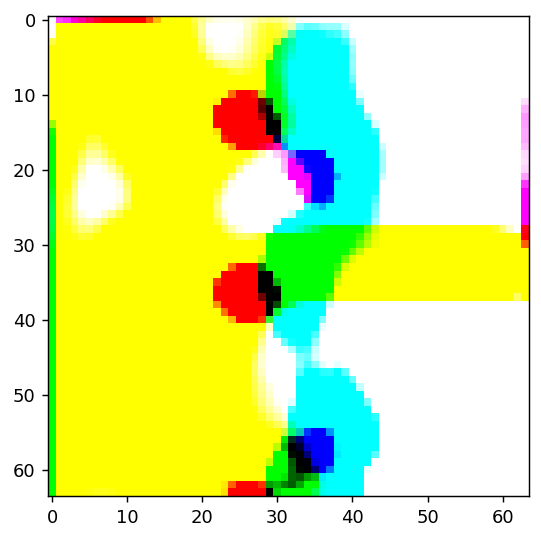

In [ ]:
plt.imshow(feats[0,:3].permute(1,2,0))

In [ ]:
# Export side-by-side route images for the steering frame window.
# Left: VEHICLE_ROUTE_NAME. Right: NO_VEHICLE_ROUTE_NAME.
import cv2
from PIL import Image, ImageDraw

COMPARE_VIDEO_FPS = 10
COMPARE_VIDEO_HEIGHT = 720
COMPARE_VIDEO_TITLE_HEIGHT = 30
VEHICLE_IMAGE_DIR = VIS_ROOT / VEHICLE_ROUTE_NAME
NO_VEHICLE_IMAGE_DIR = VIS_ROOT / NO_VEHICLE_ROUTE_NAME
COMPARE_VIDEO_PATH = VIS_ROOT / f"{VEHICLE_ROUTE_NAME}_vs_{NO_VEHICLE_ROUTE_NAME}_{STEERING_MIN_FRAMES}_{STEERING_MAX_FRAMES}.mp4"


def list_route_images(image_dir):
    image_dir = Path(image_dir)
    files = sorted(list(image_dir.glob("*.png")) + list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.jpeg")))
    out = {}
    for path in files:
        frame_idx = frame_idx_from_path(path)
        if frame_idx is not None:
            out[frame_idx] = path
    return out


def resize_to_box(image, target_width, target_height):
    image = image.convert("RGB")
    scale = min(target_width / image.width, target_height / image.height)
    new_size = (max(1, round(image.width * scale)), max(1, round(image.height * scale)))
    image = image.resize(new_size, Image.BILINEAR)

    canvas = Image.new("RGB", (target_width, target_height), (0, 0, 0))
    offset = ((target_width - image.width) // 2, (target_height - image.height) // 2)
    canvas.paste(image, offset)
    return canvas


def add_panel_title(image, title, height=30):
    canvas = Image.new("RGB", (image.width, image.height + height), (20, 20, 20))
    canvas.paste(image, (0, height))
    draw = ImageDraw.Draw(canvas)
    draw.text((8, 8), title, fill=(240, 240, 240))
    return canvas


vehicle_images = list_route_images(VEHICLE_IMAGE_DIR)
no_vehicle_images = list_route_images(NO_VEHICLE_IMAGE_DIR)
common_image_frames = sorted(set(vehicle_images) & set(no_vehicle_images))
selected_image_frames = common_image_frames[STEERING_MIN_FRAMES:STEERING_MAX_FRAMES]

if not selected_image_frames:
    raise FileNotFoundError(
        f"No common route images in frame slice [{STEERING_MIN_FRAMES}:{STEERING_MAX_FRAMES}] "
        f"for {VEHICLE_IMAGE_DIR} and {NO_VEHICLE_IMAGE_DIR}"
    )

sample_image = Image.open(vehicle_images[selected_image_frames[0]])
panel_width = max(1, round(sample_image.width * COMPARE_VIDEO_HEIGHT / sample_image.height))
frame_size = (panel_width * 2, COMPARE_VIDEO_HEIGHT + COMPARE_VIDEO_TITLE_HEIGHT)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(COMPARE_VIDEO_PATH), fourcc, COMPARE_VIDEO_FPS, frame_size)
if not writer.isOpened():
    raise RuntimeError(f"Could not open video writer for {COMPARE_VIDEO_PATH}")

print("video frames:", len(selected_image_frames), "frame slice:", (STEERING_MIN_FRAMES, STEERING_MAX_FRAMES))
try:
    for idx, frame_idx in enumerate(selected_image_frames):
        left = resize_to_box(Image.open(vehicle_images[frame_idx]), panel_width, COMPARE_VIDEO_HEIGHT)
        right = resize_to_box(Image.open(no_vehicle_images[frame_idx]), panel_width, COMPARE_VIDEO_HEIGHT)
        left = add_panel_title(left, f"vehicle | frame {frame_idx:04d}", COMPARE_VIDEO_TITLE_HEIGHT)
        right = add_panel_title(right, f"no vehicle | frame {frame_idx:04d}", COMPARE_VIDEO_TITLE_HEIGHT)

        combined = Image.new("RGB", frame_size, (0, 0, 0))
        combined.paste(left, (0, 0))
        combined.paste(right, (panel_width, 0))
        writer.write(cv2.cvtColor(np.asarray(combined), cv2.COLOR_RGB2BGR))

        if (idx + 1) % 50 == 0 or idx + 1 == len(selected_image_frames):
            print(f"wrote {idx + 1}/{len(selected_image_frames)} frames")
finally:
    writer.release()

print("saved:", COMPARE_VIDEO_PATH.resolve())

video frames: 31 frame slice: (200, 231)
wrote 31/31 frames
saved: /media/hcis-s20/SRL/osu_fail2drive/fail2drive/viz_vehicle/Generalization_VehicleOnRoad_1085_route0_05_06_18_26_03_vs_Generalization_NoVehicleOnRoad_1085_route0_05_06_18_22_39_200_231.mp4


In [36]:
import torch
from pathlib import Path
import matplotlib.pyplot as plt

dir = Path("./debug") / Path("Generalization_VehicleOnRoad_1085_route0_05_15_17_27_14")

def list_paths(dir):
    return sorted(Path(dir).glob("*.pt"))

paths = list_paths(dir)
print(paths[(324-5)*2])

debug/Generalization_VehicleOnRoad_1085_route0_05_15_17_27_14/000324.pt


In [38]:
feats = torch.load(paths[0])
print(feats.shape)

torch.Size([1, 256])


/tmp/ipykernel_398622/3044257207.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feats = torch.load(paths[0])


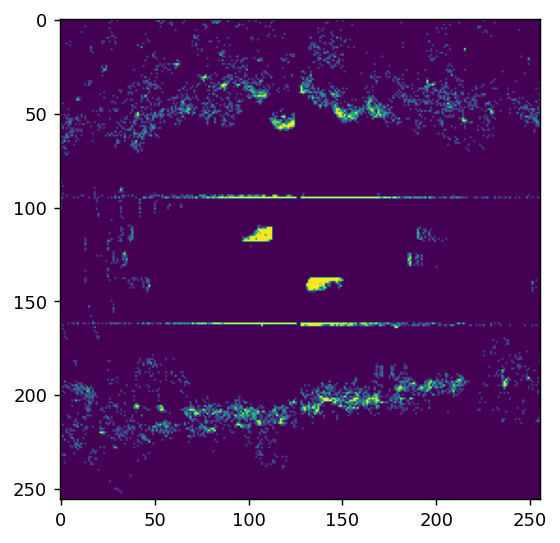

In [20]:
plt.imshow(feats[0,0])

In [42]:
feats = []
for i in range(328-302):
    feats.append(torch.load(paths[(302+i-5)*2]))
    # print(paths[(302+i-5)*2])

/tmp/ipykernel_398622/4045366432.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feats.append(torch.load(paths[(302+i-5)*2]))


In [43]:
feats = torch.cat(feats, dim=0)
print(feats.shape)
feats = feats.mean(0)
torch.save(feats, "./steering/steering_predspeed.pt")
# feats = torch.concat((feats, feats.mean(0)[None]), dim=0)

torch.Size([26, 256])


In [44]:
feats.shape

torch.Size([256])

In [3]:
import torch
path = "./steering_feats/brake_minus_normal.pt"
brake_minus = torch.load(path)

path = "./steering_feats/brake_mean.pt"
brake_mean = torch.load(path)

path = "./steering_feats/normal_mean.pt"
normal_mean = torch.load(path)

print(torch.norm(brake_minus))
print(torch.norm(brake_mean))
print(torch.norm(normal_mean))

tensor(5.9260)
tensor(8.3186)
tensor(7.9416)


/tmp/ipykernel_4132729/2702167717.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  brake_minus = torch.load(path)
/tmp/ipykernel_4132729/2702167717.py:6: FutureWarning: Y

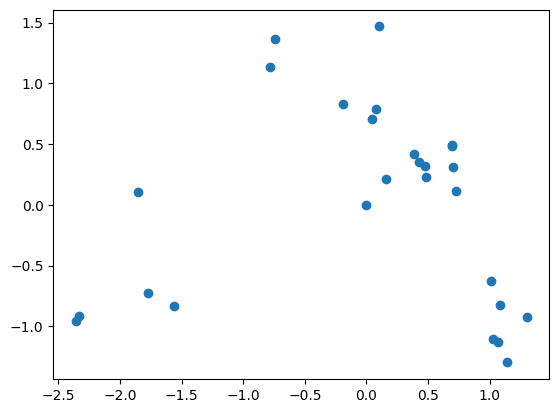

In [28]:
import matplotlib

# Compatibility for newer IPython/matplotlib-inline with older matplotlib.
if not hasattr(matplotlib.rcParams, "_get"):
    matplotlib.rcParams._get = matplotlib.rcParams.get
    
plt.scatter(pca_result[:,0], pca_result[:,1])

In [2]:
import torch
path = "./steering/hipad/post_process/left_change_lane/steering_vector.pt"
feats = torch.load(path)

/tmp/ipykernel_2844186/131661797.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  feats = torch.load(path)


In [3]:
feats.shape

torch.Size([1, 48, 256])

In [5]:
feats[0,:,0]

tensor([ 0.3189,  3.4589,  1.2665,  0.9538,  3.5108,  3.1796,  0.9774,  2.3365,
         2.0803,  2.0775,  4.2660,  2.3876, -0.0290,  0.8823,  0.6296,  3.1676,
         2.5408,  1.8928,  1.8969,  2.3479,  3.6260,  1.1686,  2.8669,  2.9184,
         2.1559,  2.8566,  1.2469,  5.8415,  2.3838,  1.0985,  0.7568,  3.0369,
         2.6748,  2.0012, -0.5119,  0.9423,  2.3990,  1.9741,  2.0915,  1.6875,
         0.1843,  2.1488,  0.9816,  3.0112,  2.2439,  2.2764,  1.2453,  1.0490])